In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ratings = pd.read_csv(
    r"C:\Users\LOQ\Desktop\Project 2\data\raw\rating.csv",
    usecols=['userId', 'movieId', 'rating'],
    dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'}
)
ratings.head()

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


In [5]:
movies = pd.read_csv(r"C:\Users\LOQ\Desktop\Project 2\data\raw\movie.csv")

title_of = dict(zip(movies.movieId, movies.title))
genre_of = dict(zip(movies.movieId, movies.genres))

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [11]:
new_data = ratings.merge(movies, on='movieId')

In [12]:
new_data.head()

,userId,movieId,rating,title,genres
0,1,2,3.5,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [18]:
print(f"{'Null count of the columns':=^50}")
print("userId:", new_data['userId'].isnull().sum())
print("movieId:", new_data['movieId'].isnull().sum())
print("rating:", new_data['rating'].isnull().sum())
print("title:", new_data['title'].isnull().sum())
print("genres:", new_data['genres'].isnull().sum())

============Null count of the columns=============
userId: 0
movieId: 0
rating: 0
title: 0
genres: 0


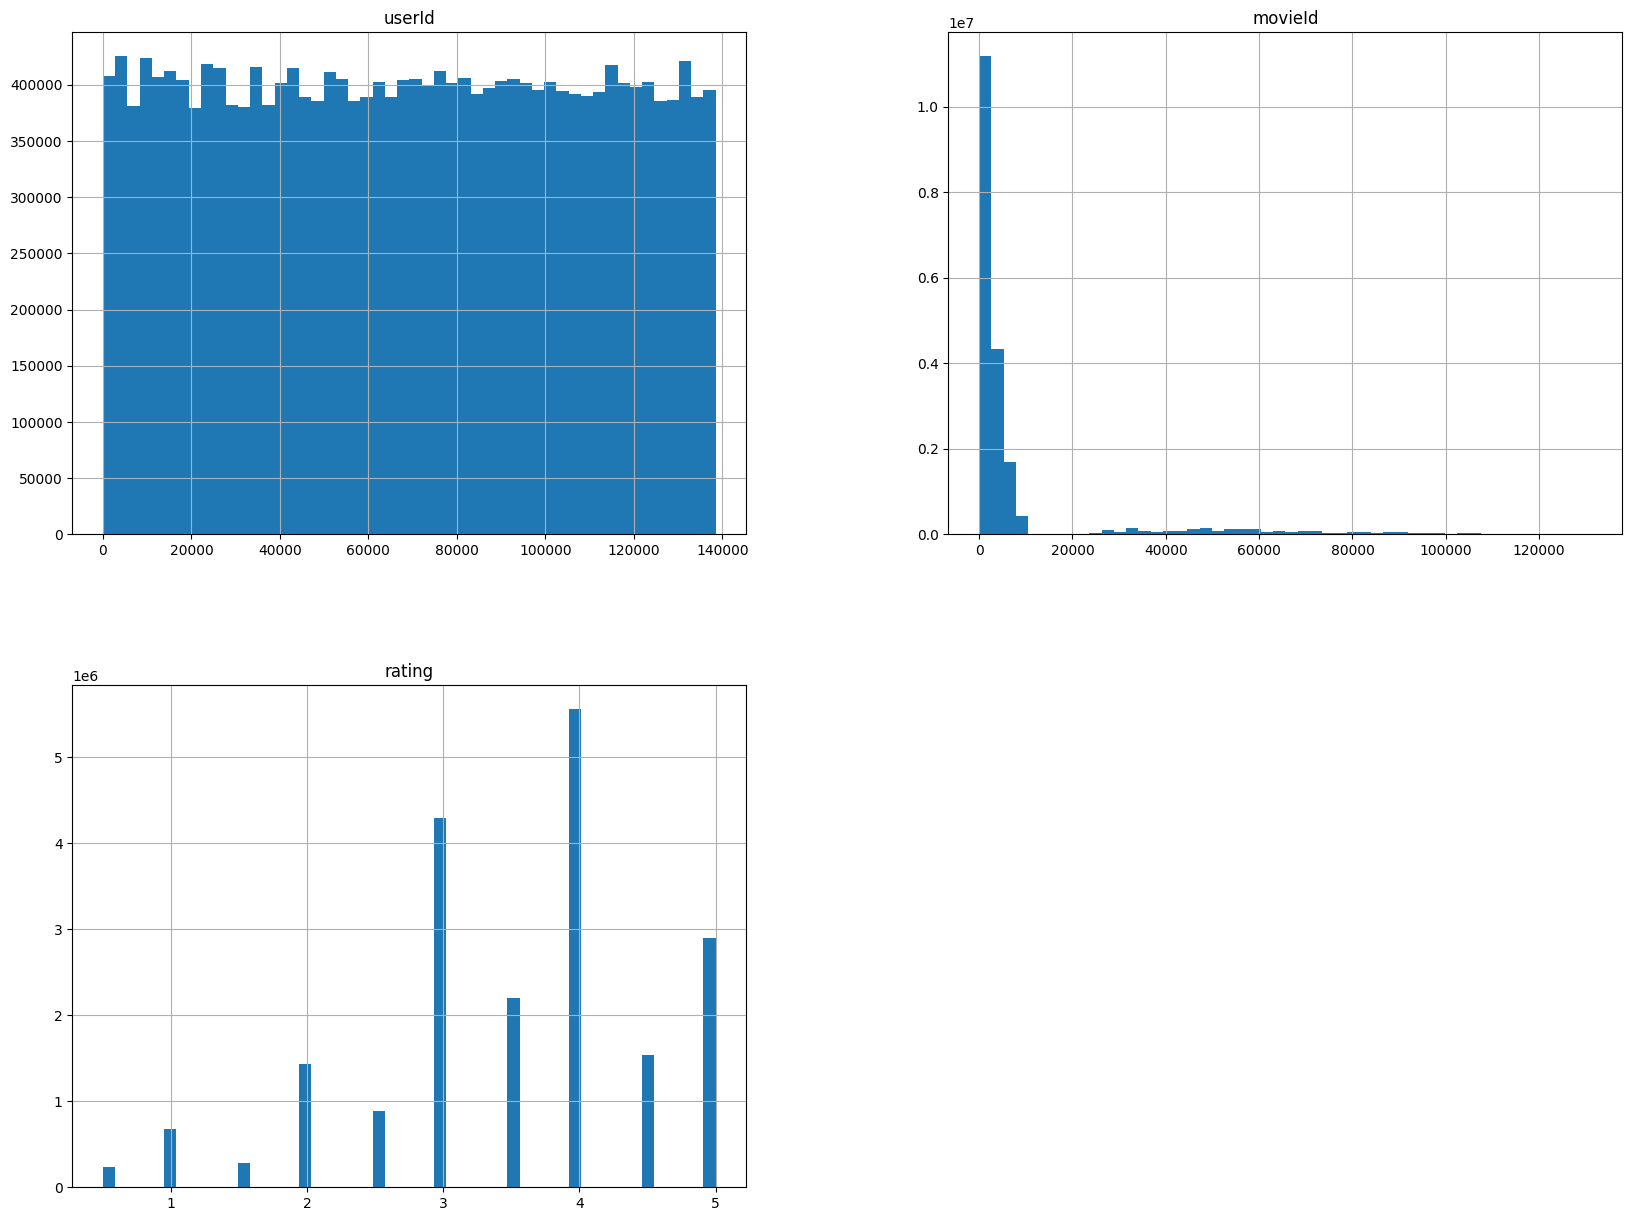

In [27]:
new_data.hist(bins=50,figsize=(20,15))
plt.show()

<Axes: xlabel='userId', ylabel='movieId'>

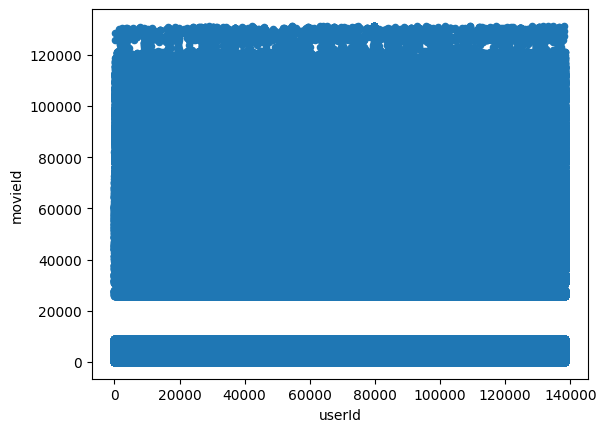

In [28]:
new_data.plot(kind='scatter', x="userId", y='movieId')


<Axes: xlabel='rating', ylabel='Density'>

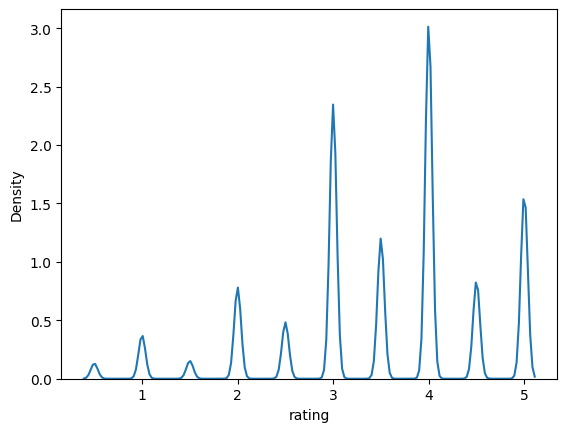

In [29]:
sns.kdeplot(new_data['rating'])

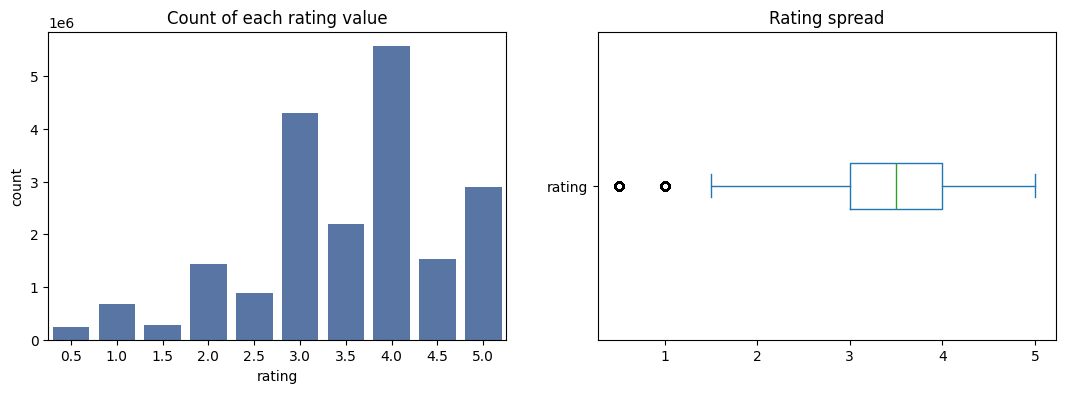

mean  : 3.526
median: 3.5
std   : 1.052
share >= 4.0 : 50.0%


In [30]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
sns.countplot(x='rating', data=ratings, color='#4C72B0', ax=ax[0])
ax[0].set_title('Count of each rating value')
ratings.rating.plot(kind='box', vert=False, ax=ax[1]); ax[1].set_title('Rating spread')
plt.show()

print("mean  :", round(ratings.rating.mean(),3))
print("median:", ratings.rating.median())
print("std   :", round(ratings.rating.std(),3))
print(f"share >= 4.0 : {100*(ratings.rating>=4).mean():.1f}%")

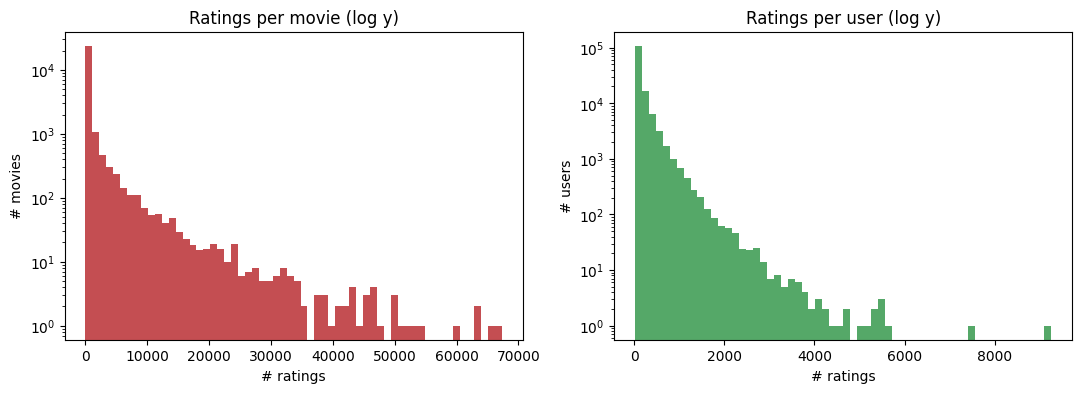

A movie's ratings — median: 18 | max: 67310
A user's ratings  — median: 68 | max: 9254


In [31]:
ratings_per_user  = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].hist(ratings_per_movie, bins=60, color='#C44E52'); ax[0].set_yscale('log')
ax[0].set(title='Ratings per movie (log y)', xlabel='# ratings', ylabel='# movies')
ax[1].hist(ratings_per_user, bins=60, color='#55A868'); ax[1].set_yscale('log')
ax[1].set(title='Ratings per user (log y)', xlabel='# ratings', ylabel='# users')
plt.show()

print("A movie's ratings — median:", int(ratings_per_movie.median()),
      "| max:", int(ratings_per_movie.max()))
print("A user's ratings  — median:", int(ratings_per_user.median()),
      "| max:", int(ratings_per_user.max()))

In [32]:
stats = (ratings.groupby('movieId')
                .agg(n=('rating','size'), avg=('rating','mean'), std=('rating','std'))
                .reset_index())
stats['title'] = stats.movieId.map(title_of)

print("Most rated:")
display(stats.sort_values('n', ascending=False).head(10)[['title','n','avg']])

print("Highest rated (>= 100 ratings, so it's reliable):")
display(stats[stats.n>=100].sort_values('avg', ascending=False).head(10)[['title','n','avg']])

print("Most divisive (>= 100 ratings, highest disagreement):")
display(stats[stats.n>=100].sort_values('std', ascending=False).head(10)[['title','n','avg','std']])

Most rated:


,title,n,avg
293,Pulp Fiction (1994),67310,4.174231
352,Forrest Gump (1994),66172,4.029000
315,"Shawshank Redemption, The (1994)",63366,4.446990
587,"Silence of the Lambs, The (1991)",63299,4.177056
476,Jurassic Park (1993),59715,3.664741
257,Star Wars: Episode IV - A New Hope (1977),54502,4.190672
108,Braveheart (1995),53769,4.042534
583,Terminator 2: Judgment Day (1991),52244,3.931954
2486,"Matrix, The (1999)",51334,4.187186
523,Schindler's List (1993),50054,4.310175


Highest rated (>= 100 ratings, so it's reliable):


,title,n,avg
315,"Shawshank Redemption, The (1994)",63366,4.446990
843,"Godfather, The (1972)",41355,4.364732
49,"Usual Suspects, The (1995)",47006,4.334372
523,Schindler's List (1993),50054,4.310175
1195,"Godfather: Part II, The (1974)",27398,4.275640
1935,Seven Samurai (Shichinin no samurai) (1954),11611,4.274179
887,Rear Window (1954),17449,4.271334
7356,Band of Brothers (2001),4305,4.263182
895,Casablanca (1942),24349,4.258327
905,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),6525,4.256935


Most divisive (>= 100 ratings, highest disagreement):


,title,n,avg,std
1282,Santa with Muscles (1996),148,2.665540,1.782748
14912,"Room, The (2003)",156,2.426282,1.756834
12617,Expelled: No Intelligence Allowed (2008),127,2.133858,1.627454
14121,Troll 2 (1990),111,2.018018,1.602453
11667,"\\""Great Performances\""\"" Cats (1998)""",155,2.748387,1.573290
1387,Grateful Dead (1995),194,3.025773,1.557817
13076,High School Musical 3: Senior Year (2008),272,2.325368,1.532495
1352,Adrenalin: Fear the Rush (1996),142,2.309859,1.527215
104,Nobody Loves Me (Keiner liebt mich) (1994),134,3.444030,1.472378
1319,Vampire in Venice (Nosferatu a Venezia) (Nosfe...,119,3.197479,1.448580


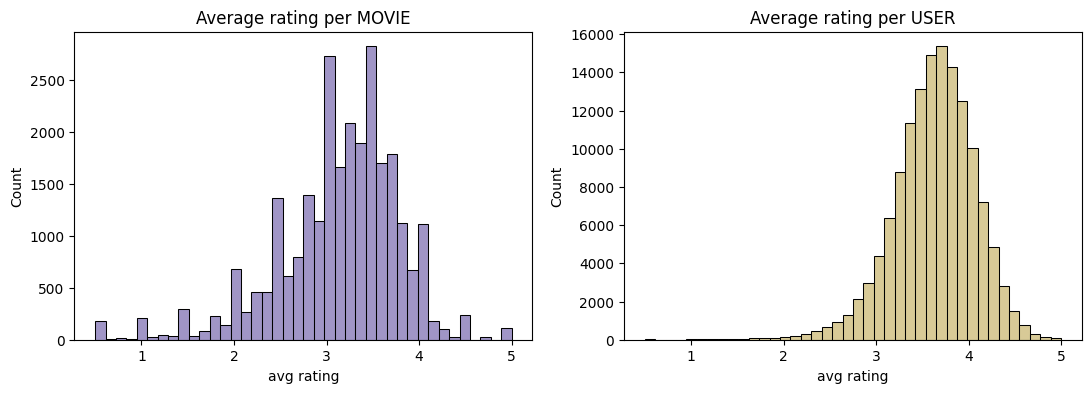

In [33]:
avg_per_movie = ratings.groupby('movieId').rating.mean()
avg_per_user  = ratings.groupby('userId').rating.mean()

fig, ax = plt.subplots(1,2, figsize=(13,4))
sns.histplot(avg_per_movie, bins=40, color='#8172B3', ax=ax[0])
ax[0].set(title="Average rating per MOVIE", xlabel='avg rating')
sns.histplot(avg_per_user, bins=40, color='#CCB974', ax=ax[1])
ax[1].set(title="Average rating per USER", xlabel='avg rating')
plt.show()

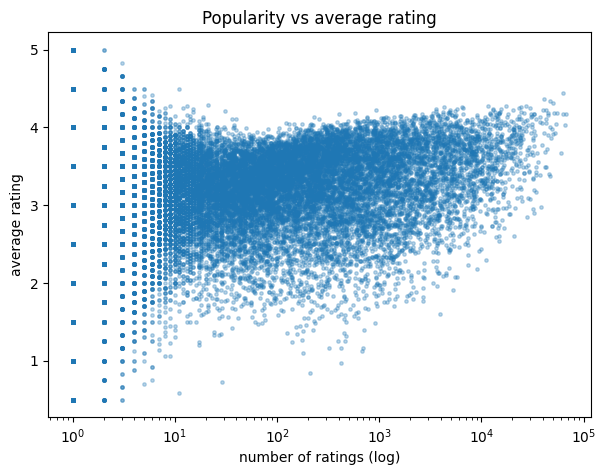

correlation (n_ratings vs avg): 0.143


In [34]:
plt.figure(figsize=(7,5))
plt.scatter(stats.n, stats.avg, s=6, alpha=0.3)
plt.xscale('log')
plt.xlabel('number of ratings (log)'); plt.ylabel('average rating')
plt.title('Popularity vs average rating')
plt.show()
print("correlation (n_ratings vs avg):", round(stats.n.corr(stats.avg), 3))

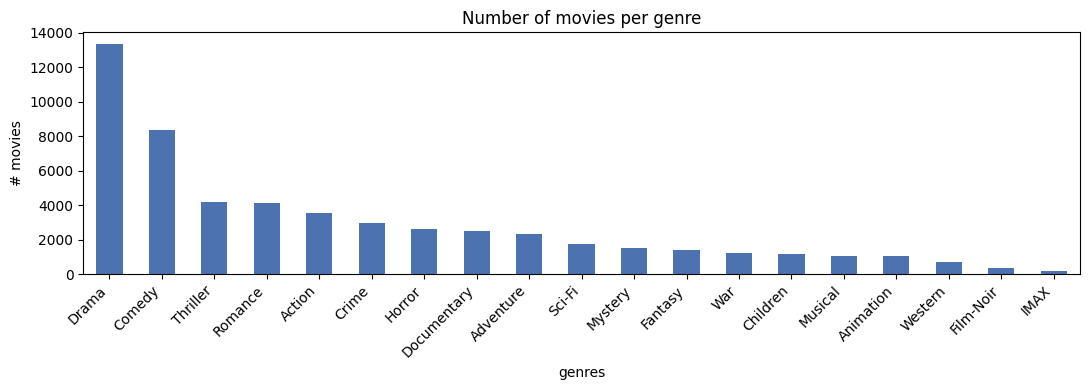

In [35]:
# explode genres to one row per (movie, genre)
g = movies.assign(genres=movies['genres'].str.split('|')).explode('genres')
g = g[g['genres'] != '(no genres listed)']

plt.figure(figsize=(11,4))
g['genres'].value_counts().plot(kind='bar', color='#4C72B0')
plt.title('Number of movies per genre'); plt.ylabel('# movies')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

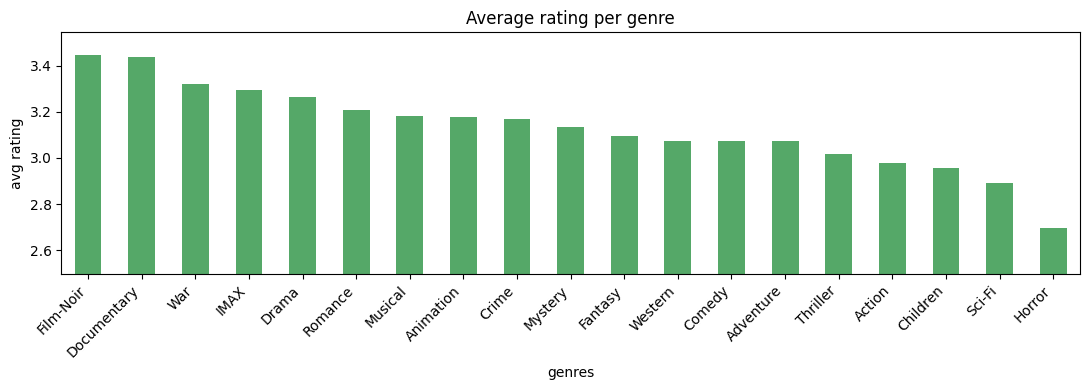

In [36]:
# average rating per genre (join ratings -> genres via movieId)
movie_avg = ratings.groupby('movieId').rating.mean().rename('avg')
gr = g.merge(movie_avg, on='movieId')
genre_avg = gr.groupby('genres')['avg'].mean().sort_values(ascending=False)

plt.figure(figsize=(11,4))
genre_avg.plot(kind='bar', color='#55A868')
plt.title('Average rating per genre'); plt.ylabel('avg rating')
plt.ylim(genre_avg.min()-0.2, genre_avg.max()+0.1)
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

genres per movie — mean: 1.99 | max: 10


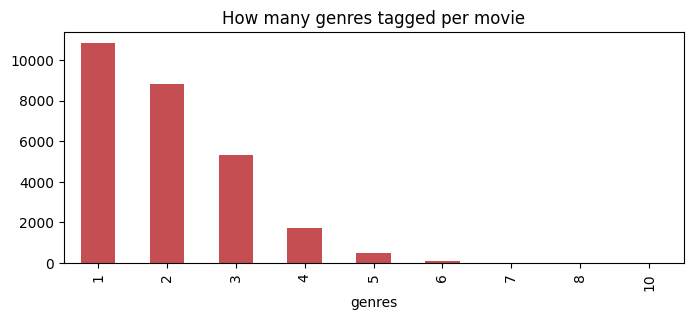

In [37]:
# how many genres does a movie usually have?
n_genres = movies['genres'].str.split('|').apply(len)
print("genres per movie — mean:", round(n_genres.mean(),2), "| max:", int(n_genres.max()))
n_genres.value_counts().sort_index().plot(kind='bar', figsize=(8,3),
    title='How many genres tagged per movie', color='#C44E52'); plt.show()

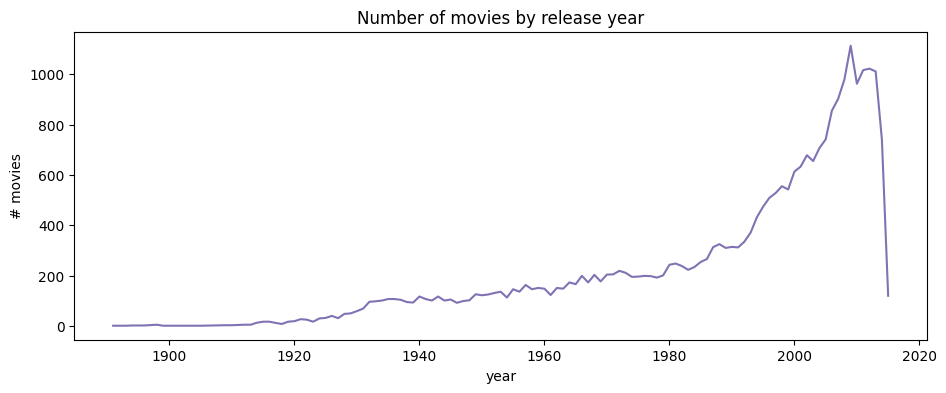

In [38]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype('float')

plt.figure(figsize=(11,4))
movies['year'].dropna().astype(int).value_counts().sort_index().plot(color='#8172B3')
plt.title('Number of movies by release year'); plt.xlabel('year'); plt.ylabel('# movies')
plt.show()

,mean,size
decade,,
1890,3.349206,63
1900,3.637048,332
1910,3.386154,1625
1920,3.834462,31159
1930,3.846493,182099
1940,3.908282,283542
1950,3.865559,460787
1960,3.806098,673405
1970,3.769576,1143995


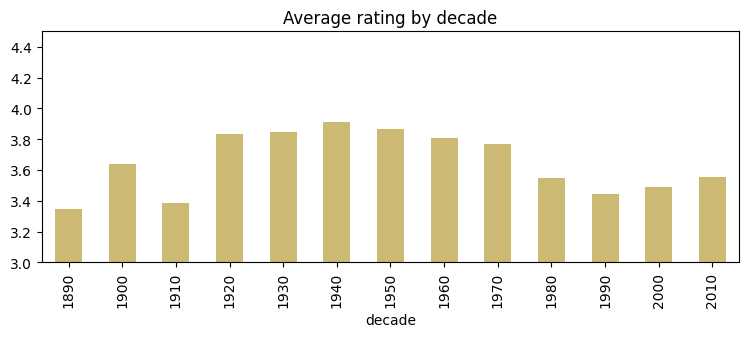

In [39]:
# average rating by decade
year_of = dict(zip(movies.movieId, movies.year))
tmp = ratings.assign(year=ratings.movieId.map(year_of)).dropna(subset=['year'])
tmp['decade'] = (tmp['year']//10*10).astype(int)
by_decade = tmp.groupby('decade').rating.agg(['mean','size'])
display(by_decade)
by_decade['mean'].plot(kind='bar', figsize=(9,3),
    title='Average rating by decade', color='#CCB974'); plt.ylim(3,4.5); plt.show()